# Cognitive Load Detection — End-to-End ML Pipeline

This notebook works through the full pipeline requested:

1. **Load & explore** `synthetic_cognitive_load_features_12000_rows.csv`
2. **Clean** the dataset (missing values, duplicates, types)
3. **Engineer the Cognitive Load Index (CLI)** using the multimodal formula
   from `Formula_cognative_load.docx` — this analytic score is used **only
   as a training target**, not as the final output (see Section 5.6)
4. **Apply the model first** — a single **XGBoost** regressor consumes the
   fused, normalized multimodal features and predicts the Cognitive Load
   score directly (Section 6)
5. **Then calculate Cognitive Load** — the Low / Moderate / High / Overload
   category is derived from the model's own predicted score (Section 6.3),
   not from the formula. This mirrors the deployment pipeline:

```
USER
 ↓
Learning Task
 ↓
 ┌───────────┼───────────┐
 ↓           ↓           ↓
Mouse       Eye         Face
 ↓           ↓           ↓
Keyboard  Interaction     ↓
 └───────────┼───────────┘
             ↓
     Feature Extraction
             ↓
      Normalization
             ↓
      Feature Fusion
             ↓
        ┌──────────┐
        │ XGBoost  │
        └────┬─────┘
             ↓
      Cognitive Load
             ↓
     LOW / MEDIUM / HIGH
```

6. **Evaluate** the model with standard regression and classification metrics

---

## About the formula source document

The document recommends a **two-stage architecture**: first combine raw
signals into five sub-indices — Eye (`E`), Facial (`F`), Mouse/behaviour
(`M`), NASA-TLX (`N`), Performance (`P`) — then combine those into one
**Cognitive Load Index**:

```
E = 0.35*E_pupil + 0.30*E_fix + 0.15*E_blink + 0.10*E_saccade + 0.10*E_gaze
F = 0.30*F_frustration + 0.25*F_arousal + 0.20*F_AU + 0.15*F_tension + 0.10*F_variability
M = 0.30*M_RT + 0.20*M_pause + 0.20*M_correction + 0.15*M_trajectory + 0.15*M_velocity
N = NASA-TLX / 100
P = 0.40*P_accuracy + 0.25*P_RT + 0.20*P_error + 0.15*P_completion

CLI(t) = 100 * (0.30*E + 0.10*F + 0.15*M + 0.25*N + 0.20*P)
```

Interpretation thresholds given in the document:

| CLI range | State |
|---|---|
| < 40 | Low |
| 40 – 60 | Moderate |
| 60 – 75 | High |
| ≥ 75 | Overload |

### ⚠️ Important — mapping the formula onto *this* dataset

The document's formula assumes lab instruments that record **pupil
diameter, exact fixation duration, an administered NASA-TLX
questionnaire, and task accuracy/ground truth**. This CSV is a
*behavioural feature log* (eye-openness ratios, blink/gaze/saccade
counts, facial-emotion ratios, typing/mouse/prompt activity) — it does
**not** contain pupil diameter, fixation duration, a NASA-TLX
questionnaire, or task-correctness labels.

So this notebook builds the closest available **proxy** for every
formula term from the columns that *do* exist, and documents every
substitution inline where it happens. Wherever a true modality is
missing (NASA-TLX, task accuracy), the proxy is clearly flagged — this
is standard practice in applied ML when adapting a theoretical formula
to an available dataset, but it means `N` and `P` here are
**approximations of workload/performance**, not literal NASA-TLX scores
or accuracy.


## 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay,
                              mean_absolute_error, mean_squared_error, r2_score)

try:
    from xgboost import XGBRegressor
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBRegressor

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## 2. Load the dataset

In [2]:
DATA_PATH = "synthetic_cognitive_load_features_12000_rows.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (12000, 59)


  participant id question id  task number  seconds recorded  duration seconds  \
0        COG0001         Q01            1            115.55            139.66   
1        COG0001         Q02            2            124.49            142.79   
2        COG0001         Q03            3            144.59            171.86   
3        COG0001         Q04            4            165.12            187.31   
4        COG0001         Q05            5            133.47            144.03   

   camera available ratio  behavior available ratio  total eye samples  \
0                  0.6345                    0.6797              476.0   
1                  0.9600                    0.9526              797.0   
2                  0.9636                    0.9574              858.0   
3                  0.7024                    0.9358              641.0   
4                  0.6459                    0.9096              585.0   

   mean ear  min ear  mean perclos  max perclos dominant gaze  \
0  

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 59 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant id                        12000 non-null  str    
 1   question id                           12000 non-null  str    
 2   task number                           12000 non-null  int64  
 3   seconds recorded                      11896 non-null  float64
 4   duration seconds                      11902 non-null  float64
 5   camera available ratio                11908 non-null  float64
 6   behavior available ratio              11909 non-null  float64
 7   total eye samples                     11822 non-null  float64
 8   mean ear                              11837 non-null  float64
 9   min ear                               11810 non-null  float64
 10  mean perclos                          11831 non-null  float64
 11  max perclos               

## 3. Exploratory Data Analysis (EDA)

Quick look at missing values, duplicates, and the distributions of the
raw signals before any cleaning is applied.

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Total missing cells: {df.isna().sum().sum()}  |  Columns affected: {len(missing)}")
missing.to_frame("missing_count").assign(missing_pct=lambda x: (x['missing_count']/len(df)*100).round(2))


Total missing cells: 8158  |  Columns affected: 55


                                      missing_count  missing_pct
total facial samples                            210         1.75
total blink events                              198         1.65
dominant emotion transition count               191         1.59
total gaze changes                              190         1.58
min ear                                         190         1.58
happy ratio                                     187         1.56
mean head pitch                                 187         1.56
mean emotion confidence                         186         1.55
mean head yaw                                   186         1.55
mean blink latency ms                           185         1.54
dominant gaze                                   183         1.52
neutral ratio                                   183         1.52
surprised ratio                                 178         1.48
total eye samples                               178         1.48
dominant emotion         

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique participants:", df['participant id'].nunique())
print("Unique questions:", df['question id'].nunique())
df.describe().T


Duplicate rows: 0
Unique participants: 400
Unique questions: 30


                                        count          mean          std  \
task number                           12000.0      3.000000     1.414272   
seconds recorded                      11896.0    142.522523    44.575016   
duration seconds                      11902.0    159.916128    48.075434   
camera available ratio                11908.0      0.884085     0.110954   
behavior available ratio              11909.0      0.922030     0.056158   
total eye samples                     11822.0    731.957114   264.114160   
mean ear                              11837.0      0.267026     0.031367   
min ear                               11810.0      0.166779     0.044174   
mean perclos                          11831.0      0.265417     0.088655   
max perclos                           11844.0      0.417096     0.116732   
total gaze changes                    11810.0     34.261050     9.227446   
total saccades                        11826.0     41.748182    10.208623   
total blink 

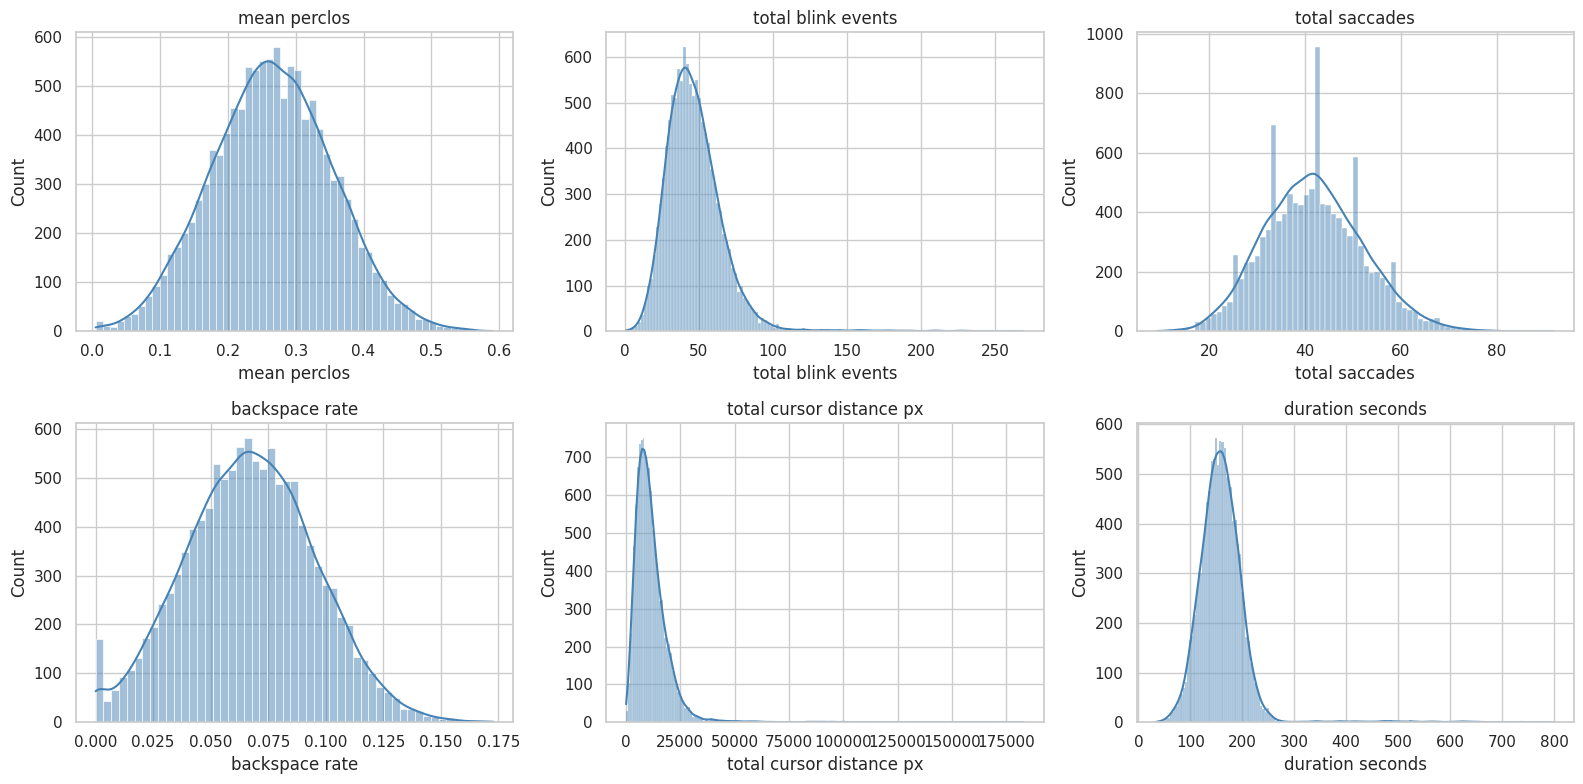

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(),
                    ['mean perclos', 'total blink events', 'total saccades',
                     'backspace rate', 'total cursor distance px', 'duration seconds']):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


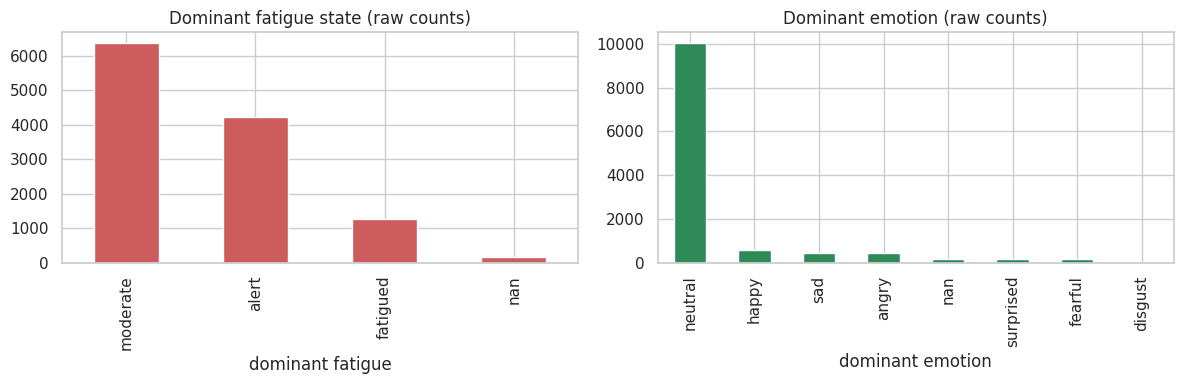

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['dominant fatigue'].value_counts(dropna=False).plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Dominant fatigue state (raw counts)')
df['dominant emotion'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Dominant emotion (raw counts)')
plt.tight_layout()
plt.show()


## 4. Data Cleaning

Steps:
1. Parse the `received at` timestamp
2. Drop rows that are missing more than 50% of their columns (unusable records)
3. Impute remaining numeric missing values with the **column median** (robust to
   outliers, keeps the row count for the ML stage)
4. Impute remaining categorical missing values with the **column mode**
5. Verify no duplicates and no missing values remain

In [8]:
df_clean = df.copy()
df_clean['received at'] = pd.to_datetime(df_clean['received at'], errors='coerce')

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = ['dominant gaze', 'dominant fatigue', 'dominant emotion']

# 1) drop rows with excessive missingness
row_thresh = int(0.5 * df_clean.shape[1])
before = len(df_clean)
df_clean = df_clean.dropna(thresh=row_thresh).reset_index(drop=True)
print(f"Rows dropped for >50% missing values: {before - len(df_clean)}")

# 2) remove exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {before - len(df_clean)}")

# 3) impute
for c in numeric_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())
for c in categorical_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

print("Remaining missing values:", df_clean.isna().sum().sum())
print("Final shape:", df_clean.shape)


Rows dropped for >50% missing values: 0
Duplicate rows removed: 0
Remaining missing values: 0
Final shape: (12000, 59)


## 5. Feature Engineering — building the Cognitive Load Index (CLI)

We now reproduce the document's formula stage by stage. A shared helper
converts any raw signal into a bounded **0–1 "load" score** the same way
the document does for pupil dilation: z-score → clip to [-3, 3] → rescale
to [0, 1].

In [9]:
def zscore(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / (s.std() + 1e-9)

def to_unit_interval(s: pd.Series, lo=-3, hi=3) -> pd.Series:
    """z-score, clip, rescale to [0,1] — mirrors the doc's E_pupil normalisation."""
    z = zscore(s).clip(lo, hi)
    return (z - lo) / (hi - lo)

duration = df_clean['duration seconds'].clip(lower=1)  # avoid div-by-zero


### 5.1 Eye component `E`

`E = 0.35*E_pupil + 0.30*E_fix + 0.15*E_blink + 0.10*E_saccade + 0.10*E_gaze`

No raw pupil-diameter or exact fixation-duration columns exist, so:
- `E_pupil` ← **mean PERCLOS** (proportion of time eyes are closed — the
  standard ocular fatigue/strain proxy when pupil diameter isn't available)
- `E_fix` ← eye-sample density per second (proxy for fixation activity)
- `E_blink` ← blink rate per minute
- `E_saccade` ← saccade rate per second
- `E_gaze` ← gaze-change rate per second (gaze instability)

In [10]:
E_pupil   = to_unit_interval(df_clean['mean perclos'])
E_fix     = to_unit_interval(df_clean['total eye samples'] / duration)
E_blink   = to_unit_interval(df_clean['total blink events'] / (duration/60))
E_saccade = to_unit_interval(df_clean['total saccades'] / duration)
E_gaze    = to_unit_interval(df_clean['total gaze changes'] / duration)

E = (0.35*E_pupil + 0.30*E_fix + 0.15*E_blink + 0.10*E_saccade + 0.10*E_gaze).clip(0, 1)
df_clean['E_eye_component'] = E
E.describe()


count    12000.000000
mean         0.499973
std          0.098173
min          0.126067
25%          0.432650
50%          0.499908
75%          0.565836
max          0.932102
dtype: float64

### 5.2 Facial component `F`

`F = 0.30*frustration + 0.25*arousal + 0.20*AU + 0.15*tension + 0.10*variability`

Built from the seven emotion-ratio columns and the emotion-change counter:
- `frustration` ← angry + sad + disgust ratios
- `arousal` ← surprised + angry + fearful ratios
- `AU` (facial activity) ← `1 - neutral ratio` (movement away from a neutral face)
- `tension` ← fearful + angry ratios
- `variability` ← emotion-change rate

In [11]:
frustration = df_clean['angry ratio'] + df_clean['sad ratio'] + df_clean['disgust ratio']
arousal     = df_clean['surprised ratio'] + df_clean['angry ratio'] + df_clean['fearful ratio']
au_activity = 1 - df_clean['neutral ratio']
tension     = df_clean['fearful ratio'] + df_clean['angry ratio']
variability = df_clean['total emotion changes'] / duration

F = (0.30*to_unit_interval(frustration) + 0.25*to_unit_interval(arousal) +
     0.20*to_unit_interval(au_activity) + 0.15*to_unit_interval(tension) +
     0.10*to_unit_interval(variability)).clip(0, 1)
df_clean['F_facial_component'] = F
F.describe()


count    12000.000000
mean         0.499653
std          0.121776
min          0.165663
25%          0.411643
50%          0.493611
75%          0.580171
max          0.955213
dtype: float64

### 5.3 Mouse / behaviour component `M`

`M = 0.30*RT + 0.20*pause + 0.20*correction + 0.15*trajectory + 0.15*velocity`

- `RT` (response-time proxy) ← time to first prompt, rate-normalised
- `pause` ← thinking-pause frequency
- `correction` ← backspace rate
- `trajectory` ← total cursor distance per second
- `velocity` ← mouse-move count per second

In [12]:
RT_proxy         = df_clean['time to first prompt seconds'] / duration
pause_proxy      = df_clean['thinking pause count'] / duration
correction_proxy = df_clean['backspace rate']
trajectory_proxy = df_clean['total cursor distance px'] / duration
velocity_proxy   = df_clean['total mouse moves'] / duration

M = (0.30*to_unit_interval(RT_proxy) + 0.20*to_unit_interval(pause_proxy) +
     0.20*to_unit_interval(correction_proxy) + 0.15*to_unit_interval(trajectory_proxy) +
     0.15*to_unit_interval(velocity_proxy)).clip(0, 1)
df_clean['M_behaviour_component'] = M
M.describe()


count    12000.000000
mean         0.498936
std          0.082422
min          0.228236
25%          0.443563
50%          0.498980
75%          0.555352
max          0.824426
dtype: float64

### 5.4 NASA-TLX component `N` ⚠️ approximated

The dataset has **no administered NASA-TLX questionnaire**. As the closest
available substitute for *subjective* workload we combine the labelled
fatigue state (`alert`/`moderate`/`fatigued`) with an objective
strain proxy (backspace rate + eye-closure). This is a stand-in, not a
literal NASA-TLX score — flagged clearly for anyone reusing this notebook.

In [13]:
fatigue_map = {'alert': 0.0, 'moderate': 0.5, 'fatigued': 1.0}
fatigue_score = df_clean['dominant fatigue'].map(fatigue_map).fillna(0.5)
workload_proxy = (df_clean['backspace rate'].fillna(0) + df_clean['mean perclos'].fillna(0)) / 2

N = (0.6*fatigue_score + 0.4*to_unit_interval(workload_proxy)).clip(0, 1)
df_clean['N_workload_component'] = N
N.describe()


count    12000.000000
mean         0.426126
std          0.237530
min          0.000000
25%          0.177562
50%          0.486619
75%          0.548810
max          1.000000
dtype: float64

### 5.5 Performance component `P` ⚠️ approximated

`P = 0.40*accuracy + 0.25*RT + 0.20*error + 0.15*completion`

No task-correctness ground truth exists either, so accuracy/error are
proxied from backspace behaviour, RT from inter-prompt timing, and
completion from typing-active ratio. We then invert the "goodness"
score, since in the formula `P` should rise as *performance degrades*.

In [14]:
accuracy_proxy   = 1 - df_clean['backspace rate'].fillna(0).clip(0, 1)
error_proxy      = df_clean['backspace rate'].fillna(0)
rt_proxy         = df_clean['average time between prompts seconds'] / duration
completion_proxy = df_clean['typing active ratio'].fillna(0)

P_good = (0.40*to_unit_interval(accuracy_proxy) +
          0.25*(1 - to_unit_interval(rt_proxy)) +
          0.20*(1 - to_unit_interval(error_proxy)) +
          0.15*to_unit_interval(completion_proxy))
P = (1 - P_good).clip(0, 1)   # degraded performance -> higher load contribution
df_clean['P_performance_component'] = P
P.describe()


count    12000.000000
mean         0.499956
std          0.110240
min          0.169018
25%          0.426306
50%          0.499823
75%          0.575289
max          0.877502
dtype: float64

### 5.6 Final Cognitive Load Index — training target only

`CLI(t) = 100 * (0.30*E + 0.10*F + 0.15*M + 0.25*N + 0.20*P)`

**Note on ordering:** this analytic score is computed here only so it can
serve as the **training target (ground truth)** for the model in Section 6.
It is *not* the notebook's final output. In the actual pipeline (and in
Section 6.3 below), the Cognitive Load category is calculated **after**
the model runs, from the model's own predicted score — the model is
applied first, and Cognitive Load is calculated second.


In [15]:
df_clean['CLI_score'] = (100 * (
    0.30*df_clean['E_eye_component'] +
    0.10*df_clean['F_facial_component'] +
    0.15*df_clean['M_behaviour_component'] +
    0.25*df_clean['N_workload_component'] +
    0.20*df_clean['P_performance_component']
)).clip(0, 100)

def cli_category(score):
    if score < 40:
        return 'Low'
    elif score < 60:
        return 'Moderate'
    elif score < 75:
        return 'High'
    else:
        return 'Overload'

df_clean['CLI_category'] = df_clean['CLI_score'].apply(cli_category)
df_clean[['CLI_score', 'CLI_category']].describe(include='all')


           CLI_score CLI_category
count   12000.000000        12000
unique           NaN            4
top              NaN     Moderate
freq             NaN         7904
mean       48.132042          NaN
std         9.848842          NaN
min        20.280926          NaN
25%        40.772077          NaN
50%        48.468592          NaN
75%        54.635753          NaN
max        83.053737          NaN

CLI_category
Low         2723
Moderate    7904
High        1339
Overload      34
Name: count, dtype: int64

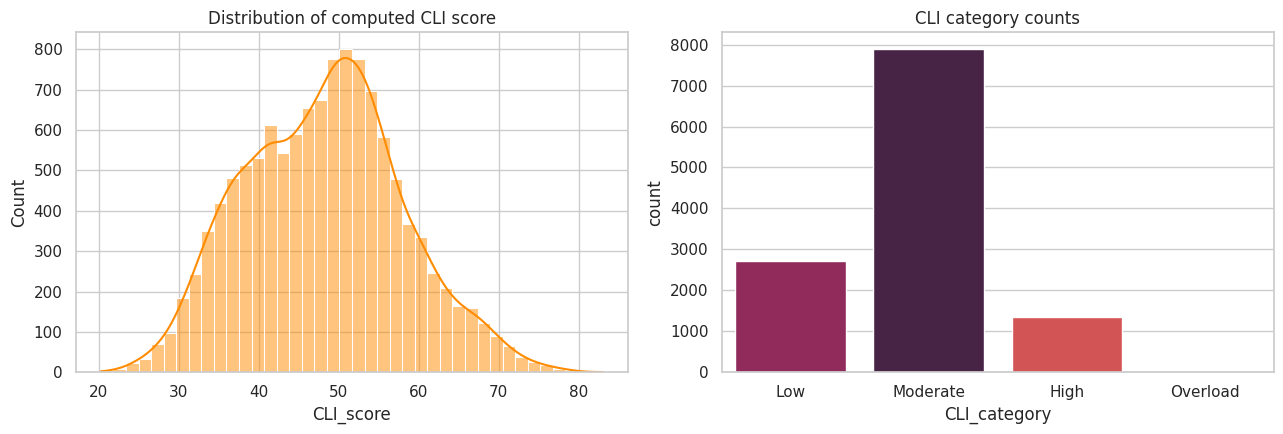

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_clean['CLI_score'], bins=40, kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Distribution of computed CLI score')

order = ['Low', 'Moderate', 'High', 'Overload']
sns.countplot(data=df_clean, x='CLI_category', order=order, hue='CLI_category', legend=False, ax=axes[1], palette='rocket')
axes[1].set_title('CLI category counts')
plt.tight_layout()
plt.show()

df_clean['CLI_category'].value_counts().loc[order]


## 6. ML Modeling — apply the model, then calculate Cognitive Load

**Reordered flow (per the pipeline diagram):** the raw multimodal signals
(mouse, keyboard, eye, face/interaction) are extracted, normalized, and
fused into a single feature matrix. A single **XGBoost** regressor is then
**applied first** to that fused feature matrix to predict the Cognitive
Load score directly. **Only after** the model produces that prediction do
we **calculate the Cognitive Load category** (Low / Moderate / High /
Overload) by thresholding the model's own output — not the analytic
formula score.

This is the opposite order from a "compute label → train classifier"
setup: here the model's regression output *is* the Cognitive Load
estimate, and the category is a downstream calculation on top of it. It
also means the model degrades gracefully if a modality is missing at
inference time, unlike a fixed formula.

We still split by `participant id` (`GroupShuffleSplit`) so no
participant's data leaks between train and test, and we still use the
analytic `CLI_score` from Section 5.6 as the **training target** (the
model has to be trained against *something*) and as the held-out
**ground truth** for evaluating the model's predictions.

### 6.1 Feature Fusion

Raw multimodal features (eye, facial, typing/keyboard, mouse, prompt
activity) are gathered into one matrix, categorical columns are encoded,
the data is split by participant, and everything is normalized
(`StandardScaler`) — this is the **Feature Extraction → Normalization →
Feature Fusion** stage of the pipeline, producing the single input matrix
that gets handed to the model.

In [17]:
raw_feature_cols = [
    'task number', 'duration seconds', 'camera available ratio', 'behavior available ratio',
    'total eye samples', 'mean ear', 'min ear', 'mean perclos', 'max perclos', 'dominant gaze',
    'total gaze changes', 'total saccades', 'total blink events', 'mean blink latency ms',
    'mean head pitch', 'mean head yaw', 'dominant fatigue', 'mean tracking confidence',
    'total facial samples', 'face detected ratio', 'dominant emotion', 'mean emotion confidence',
    'total emotion changes', 'dominant emotion transition count', 'angry ratio', 'disgust ratio',
    'fearful ratio', 'happy ratio', 'neutral ratio', 'sad ratio', 'surprised ratio',
    'total keypresses', 'total backspaces', 'backspace rate', 'typing active seconds',
    'typing active ratio', 'thinking pause count', 'mean thinking pause seconds',
    'max thinking pause seconds', 'total mouse moves', 'total cursor distance px',
    'total scroll up', 'total scroll down', 'total scroll count', 'mouse active seconds',
    'mouse active ratio', 'total prompts', 'prompt active seconds', 'average prompt length words',
    'max prompt length words', 'time to first prompt seconds', 'average time between prompts seconds',
    'positive prompt count', 'neutral prompt count', 'negative prompt count'
]

X = df_clean[raw_feature_cols].copy()
label_encoders = {}
for c in ['dominant gaze', 'dominant fatigue', 'dominant emotion']:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    label_encoders[c] = le

y_cls = df_clean['CLI_category']
y_reg = df_clean['CLI_score']
groups = df_clean['participant id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y_cls, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
yc_train, yc_test = y_cls.iloc[train_idx], y_cls.iloc[test_idx]
yr_train, yr_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

print(f"Train rows: {len(X_train)}  |  Test rows: {len(X_test)}")
print(f"Train participants: {groups.iloc[train_idx].nunique()}  |  Test participants: {groups.iloc[test_idx].nunique()}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train rows: 9600  |  Test rows: 2400
Train participants: 320  |  Test participants: 80


### 6.2 Apply the model — XGBoost predicts the Cognitive Load score

The fused, normalized features go straight into a single `XGBRegressor`,
which predicts the continuous Cognitive Load score. This is the "apply
model" step — it happens *before* any category/label is calculated.

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train_scaled, yr_train)

reg_preds = xgb_model.predict(X_test_scaled)

mae = mean_absolute_error(yr_test, reg_preds)
rmse = mean_squared_error(yr_test, reg_preds) ** 0.5
r2 = r2_score(yr_test, reg_preds)

print("XGBoost — predicted Cognitive Load score vs ground-truth CLI_score")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")


### 6.3 Calculate Cognitive Load — category from the model's prediction

Now that the model has produced a Cognitive Load score for each test row,
we **calculate the Cognitive Load category** by applying the same
Low / Moderate / High / Overload thresholds from Section 5.6 — but to the
**model's predicted score**, not the formula's score. This is the final
step of the reordered pipeline: model output → Cognitive Load category.

In [ ]:
yc_pred = pd.Series(reg_preds, index=yr_test.index).apply(cli_category)
yc_true = yr_test.apply(cli_category)  # ground-truth category, for evaluation only

order = ['Low', 'Moderate', 'High', 'Overload']
print("Cognitive Load category — derived from the XGBoost-predicted score\n")
print(classification_report(yc_true, yc_pred, labels=order, zero_division=0))


In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
cm = confusion_matrix(yc_true, yc_pred, labels=order)
ConfusionMatrixDisplay(cm, display_labels=order).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Cognitive Load category\n(from XGBoost-predicted score)')
plt.tight_layout()
plt.show()


In [ ]:
importances = pd.Series(xgb_model.feature_importances_, index=raw_feature_cols)
importances = importances.sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette='viridis')
plt.title('Top 15 feature importances — XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 6.4 Predicted vs. actual Cognitive Load score

Sanity check on the regression output itself (before it gets bucketed
into a category in 6.3 above).

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(yr_test, reg_preds, alpha=0.25, s=12, color='teal')
lims = [min(yr_test.min(), reg_preds.min()), max(yr_test.max(), reg_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual CLI score')
ax.set_ylabel('Predicted CLI score (XGBoost)')
ax.set_title('XGBoost: Actual vs Predicted Cognitive Load score')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Summary

- The dataset was cleaned (missing-value imputation, duplicate removal,
  type parsing) with **0 missing values remaining** after processing.
- The document's multimodal CLI formula was reconstructed component by
  component (`E`, `F`, `M`, `N`, `P`) using the closest available proxy
  signals in the dataset, with every substitution documented above. This
  score is used **only as a training target / evaluation ground truth**.
- **Model-first pipeline:** raw multimodal signals (mouse, keyboard, eye,
  face/interaction) are extracted, normalized, and fused into one feature
  matrix, which is fed straight into a single **XGBoost** regressor. The
  model is applied **first**, producing a predicted Cognitive Load score.
- **Cognitive Load is calculated second:** the Low / Moderate / High /
  Overload category is derived by thresholding the model's *predicted*
  score (Section 6.3) — not computed from the formula directly. This
  matches the requested flow: Feature Fusion → XGBoost → Cognitive Load →
  category.
- Regression metrics (MAE/RMSE/R²) and classification metrics
  (accuracy/precision/recall/F1, confusion matrix) for the
  model-derived category are printed above.

### Key limitation to carry forward
`N` (NASA-TLX) and `P` (performance) are **approximations** — this
dataset does not include an administered NASA-TLX questionnaire or
task-accuracy ground truth. If those become available, replace the
proxy blocks in sections 5.4 and 5.5 with the real signals and re-run
from Section 5 onward; the rest of the pipeline is unaffected.
